<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 40px; border-radius: 10px; margin-bottom: 20px;">
<h1 style="color: white; margin: 0; font-size: 2.5em;">Lecture 1: Introduction to Superconductivity</h1>
<p style="color: #888; font-size: 1.2em; margin-top: 10px;">Part I: Foundations — SCE Futures</p>
</div>

## Contents

- [Learning Objectives](#learning-objectives)

1. [What is Superconductivity?](#1-what-is-superconductivity)
2. [History and Key Discoveries](#2-history)
3. [Critical Parameters](#3-critical-parameters)
4. [Type I vs Type II Superconductors](#4-type-i-vs-type-ii)
5. [BCS Theory](#5-bcs-theory)
6. [Cooper Pairs and the Energy Gap](#6-cooper-pairs)
7. [Flux Quantization](#7-flux-quantization)
8. [Why Superconductor Electronics?](#8-why-sce)

---
<a id="learning-objectives"></a>
## Learning Objectives

By the end of this session, you will be able to:

- Explain the key phenomena that define superconductivity (zero resistance, Meissner effect)
- Distinguish between Type I and Type II superconductors
- Describe how BCS theory explains superconductivity through Cooper pairs
- Calculate basic superconducting parameters (energy gap, coherence length)
- Articulate why superconductivity enables ultra-low-power, high-speed electronics

---

In [1]:
# Setup: Import libraries for visualizations
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Circle
import numpy as np

# Color scheme
COLORS = {
    'primary': '#2196F3',
    'secondary': '#FF9800',
    'success': '#4CAF50',
    'danger': '#f44336',
    'dark': '#1a1a2e',
    'light': '#f5f5f5',
    'superconducting': '#00BCD4',
    'normal': '#9E9E9E'
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

print("Setup complete.")

Setup complete.


---
<a id="1-what-is-superconductivity"></a>
# 1. What is Superconductivity?
---

Superconductivity is a quantum mechanical phenomenon where certain materials, when cooled below a **critical temperature (T_c)**, exhibit two remarkable properties:

1. **Zero electrical resistance** — Current flows without any energy dissipation
2. **Perfect diamagnetism (Meissner effect)** — Magnetic fields are expelled from the interior

### Zero Resistance: Not Just "Very Low"

The resistance of a superconductor isn't just extremely small—it's exactly **zero**. This is fundamentally different from normal metals:

| Property | Normal Metal | Superconductor |
|----------|--------------|----------------|
| Resistance at low T | Decreases gradually, reaches residual value | Drops abruptly to **exactly zero** at T_c |
| Current decay | Currents decay due to dissipation | Persistent currents last indefinitely |
| Mechanism | Free electrons scatter off impurities/phonons | Cooper pairs move without scattering |

**Persistent currents** in superconducting loops have been measured to last for years with no measurable decay—experiments extrapolate lifetimes exceeding 100,000 years.

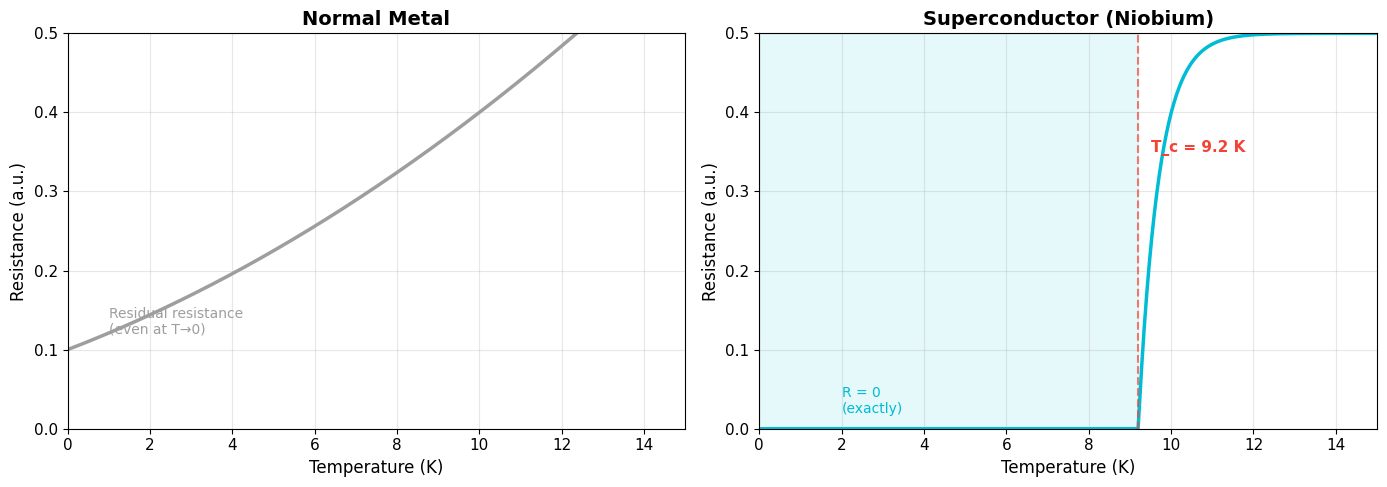

Key insight: The transition at T_c is abrupt—a phase transition, not a gradual change.


In [2]:
# Visualize: Resistance vs Temperature
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Temperature range
T = np.linspace(0, 15, 500)
Tc = 9.2  # Niobium critical temperature

# Normal metal (copper-like)
R_normal = 0.1 + 0.02 * T + 0.001 * T**2

# Superconductor (niobium-like)
R_super = np.where(T < Tc, 0, 0.5 * (1 - np.exp(-(T - Tc)/0.5)))

# Plot 1: Normal metal
ax1.plot(T, R_normal, color=COLORS['normal'], linewidth=2.5, label='Normal metal (Cu)')
ax1.set_xlabel('Temperature (K)', fontsize=12)
ax1.set_ylabel('Resistance (a.u.)', fontsize=12)
ax1.set_title('Normal Metal', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 15)
ax1.set_ylim(0, 0.5)
ax1.grid(True, alpha=0.3)
ax1.annotate('Residual resistance\n(even at T→0)', xy=(1, 0.12), fontsize=10,
             ha='left', color=COLORS['normal'])

# Plot 2: Superconductor
ax2.plot(T, R_super, color=COLORS['superconducting'], linewidth=2.5, label='Superconductor (Nb)')
ax2.axvline(x=Tc, color=COLORS['danger'], linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Temperature (K)', fontsize=12)
ax2.set_ylabel('Resistance (a.u.)', fontsize=12)
ax2.set_title('Superconductor (Niobium)', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 15)
ax2.set_ylim(0, 0.5)
ax2.grid(True, alpha=0.3)
ax2.annotate(f'T_c = {Tc} K', xy=(Tc + 0.3, 0.35), fontsize=11,
             color=COLORS['danger'], fontweight='bold')
ax2.annotate('R = 0\n(exactly)', xy=(2, 0.02), fontsize=10,
             ha='left', color=COLORS['superconducting'])
ax2.fill_between(T[T < Tc], 0, 0.5, alpha=0.1, color=COLORS['superconducting'])

plt.tight_layout()
plt.show()

print("Key insight: The transition at T_c is abrupt—a phase transition, not a gradual change.")

### The Meissner Effect

When a superconductor is cooled below T_c in a magnetic field, the field is **actively expelled** from the interior. This is called the **Meissner effect** (discovered 1933).

This is **not** simply a consequence of zero resistance:
- A hypothetical "perfect conductor" would **trap** any field present when it became perfectly conducting
- A superconductor **expels** the field, regardless of whether it was applied before or after cooling

The field penetrates only a thin surface layer called the **penetration depth (λ)**, typically 50-500 nm.

$$B(x) = B_0 e^{-x/\lambda}$$

---
<a id="2-history"></a>
# 2. History and Key Discoveries
---

| Year | Discovery | Scientists | Significance |
|------|-----------|------------|-------------|
| **1911** | Zero resistance in Hg at 4.2 K | Heike Kamerlingh Onnes | Discovery of superconductivity (Nobel 1913) |
| **1933** | Magnetic field expulsion | Meissner & Ochsenfeld | Established superconductivity as a thermodynamic phase |
| **1950** | Ginzburg-Landau theory | V.L. Ginzburg, L.D. Landau | Phenomenological description with order parameter |
| **1957** | BCS theory | Bardeen, Cooper, Schrieffer | Microscopic explanation via Cooper pairs (Nobel 1972) |
| **1961** | Flux quantization | Deaver & Fairbank; Doll & Näbauer | Proof of Cooper pairs (2e charge) |
| **1962** | Josephson effect predicted | Brian Josephson | Cooper pair tunneling (Nobel 1973) |
| **1986** | High-T_c cuprates (30 K) | Bednorz & Müller | Breakthrough in critical temperature (Nobel 1987) |
| **1987** | YBCO (93 K) | Wu, Chu, and others | First superconductor above liquid nitrogen temperature |

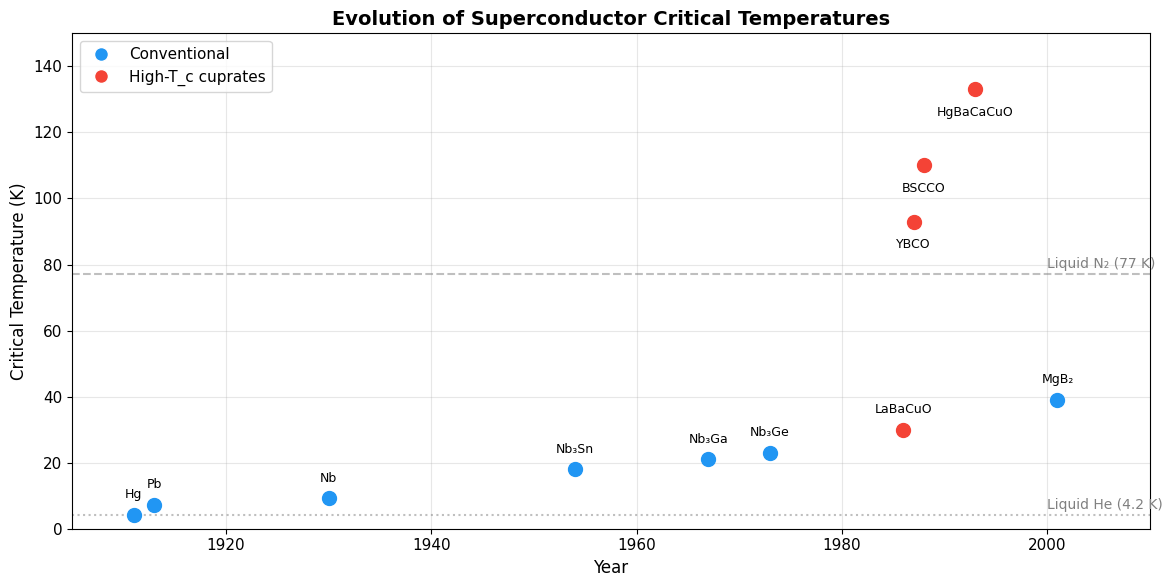

In [3]:
# Visualize: Critical temperature progress over time
fig, ax = plt.subplots(figsize=(12, 6))

# Data: (year, Tc, material, is_cuprate)
discoveries = [
    (1911, 4.2, 'Hg', False),
    (1913, 7.2, 'Pb', False),
    (1930, 9.2, 'Nb', False),
    (1954, 18, 'Nb₃Sn', False),
    (1967, 21, 'Nb₃Ga', False),
    (1973, 23, 'Nb₃Ge', False),
    (1986, 30, 'LaBaCuO', True),
    (1987, 93, 'YBCO', True),
    (1988, 110, 'BSCCO', True),
    (1993, 133, 'HgBaCaCuO', True),
    (2001, 39, 'MgB₂', False),
]

years = [d[0] for d in discoveries]
Tcs = [d[1] for d in discoveries]
materials = [d[2] for d in discoveries]
is_cuprate = [d[3] for d in discoveries]

# Plot
for i, (y, tc, mat, cup) in enumerate(discoveries):
    color = COLORS['danger'] if cup else COLORS['primary']
    ax.scatter(y, tc, s=100, color=color, zorder=5)
    offset = 5 if tc < 50 else -8
    ax.annotate(mat, (y, tc + offset), fontsize=9, ha='center')

# Reference lines
ax.axhline(y=77, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
ax.text(2000, 79, 'Liquid N₂ (77 K)', fontsize=10, color='gray')
ax.axhline(y=4.2, color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(2000, 6, 'Liquid He (4.2 K)', fontsize=10, color='gray')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Critical Temperature (K)', fontsize=12)
ax.set_title('Evolution of Superconductor Critical Temperatures', fontsize=14, fontweight='bold')
ax.set_xlim(1905, 2010)
ax.set_ylim(0, 150)
ax.grid(True, alpha=0.3)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['primary'], markersize=10, label='Conventional'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['danger'], markersize=10, label='High-T_c cuprates')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

---
<a id="3-critical-parameters"></a>
# 3. Critical Parameters
---

Superconductivity exists only within a bounded region of parameter space defined by three **critical values**:

### Critical Temperature (T_c)

The temperature below which superconductivity occurs.

| Material | T_c (K) | Type | Notes |
|----------|---------|------|-------|
| Aluminum (Al) | 1.2 | I | Used for qubits |
| Mercury (Hg) | 4.2 | I | First discovered |
| Lead (Pb) | 7.2 | I | Early applications |
| **Niobium (Nb)** | **9.2** | II | **Workhorse of SCE** |
| NbN | 16 | II | High kinetic inductance |
| Nb₃Sn | 18 | II | High-field magnets |
| MgB₂ | 39 | II | Simple compound |
| YBCO | 93 | II | Above liquid N₂ |

### Critical Magnetic Field (H_c)

Maximum external magnetic field before superconductivity is destroyed.

$$H_c(T) \approx H_c(0)\left[1 - \left(\frac{T}{T_c}\right)^2\right]$$

### Critical Current Density (J_c)

Maximum current density the material can carry while remaining superconducting. For practical superconductors: **10⁵ - 10⁶ A/cm²**

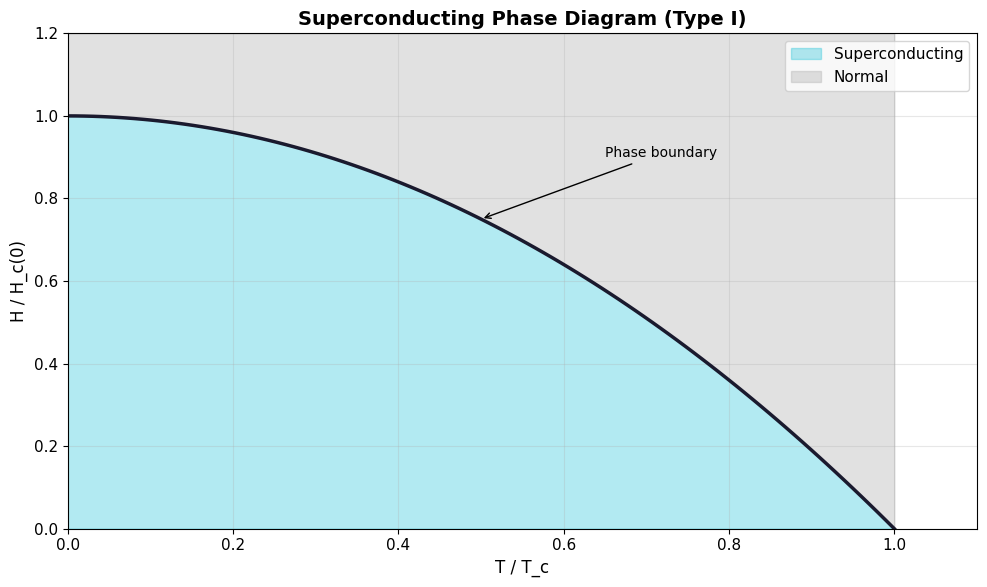

In [4]:
# Visualize: Critical surface (T, H, J space)
fig, ax = plt.subplots(figsize=(10, 6))

# Simplified 2D phase diagram (T vs H)
T_range = np.linspace(0, 1, 100)  # Normalized T/Tc
H_c = 1 - T_range**2  # Normalized critical field

ax.fill_between(T_range, H_c, 0, alpha=0.3, color=COLORS['superconducting'], label='Superconducting')
ax.fill_between(T_range, H_c, 1.2, alpha=0.3, color=COLORS['normal'], label='Normal')
ax.plot(T_range, H_c, color=COLORS['dark'], linewidth=2.5)

ax.set_xlabel('T / T_c', fontsize=12)
ax.set_ylabel('H / H_c(0)', fontsize=12)
ax.set_title('Superconducting Phase Diagram (Type I)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.set_ylim(0, 1.2)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Annotations
ax.annotate('Phase boundary', xy=(0.5, 0.75), xytext=(0.65, 0.9),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.tight_layout()
plt.show()

---
<a id="4-type-i-vs-type-ii"></a>
# 4. Type I vs Type II Superconductors
---

Superconductors are classified by how they respond to magnetic fields:

| Property | Type I | Type II |
|----------|--------|--------|
| **Examples** | Pb, Hg, Sn, Al | **Nb**, NbTi, NbN, YBCO |
| **Critical fields** | Single H_c (< 0.2 T) | Two: H_c1 and H_c2 (can exceed 100 T) |
| **Magnetic behavior** | Complete Meissner effect | Partial flux penetration (mixed state) |
| **Phase transition** | First-order (abrupt) | Second-order at H_c2 |
| **GL parameter κ** | κ < 1/√2 ≈ 0.71 | κ > 1/√2 |
| **Practical use** | Limited | **Most applications** |

### The Ginzburg-Landau Parameter

$$\kappa = \frac{\lambda}{\xi}$$

where:
- **λ** = penetration depth (how far magnetic field penetrates)
- **ξ** = coherence length (size of Cooper pairs)

### Type II: The Mixed (Vortex) State

Between H_c1 and H_c2, magnetic flux penetrates as **quantized vortices** (flux tubes):
- Each vortex carries exactly one **flux quantum**: Φ₀ = h/2e = 2.07 × 10⁻¹⁵ Wb
- Vortices arrange in a regular **Abrikosov lattice** (typically hexagonal)
- **Flux pinning** by defects prevents vortex motion, enabling high current transport

**Type II superconductors dominate practical applications** because of their higher critical temperatures and fields.

---
<a id="5-bcs-theory"></a>
# 5. BCS Theory
---

The **Bardeen-Cooper-Schrieffer (BCS) theory** (1957) provides the microscopic explanation for conventional superconductivity.

### The Key Insight: Electrons Can Attract

In a metal, electrons normally repel each other (Coulomb repulsion). But through **phonon-mediated interaction**, they can experience a net attraction:

1. An electron moving through the lattice **attracts nearby positive ions**
2. This creates a local region of **increased positive charge density**
3. A second electron is **attracted to this positive region**
4. Net effect: **effective attraction** between electrons mediated by lattice vibrations (phonons)

The interaction is **retarded** (not instantaneous)—this is crucial for overcoming Coulomb repulsion.

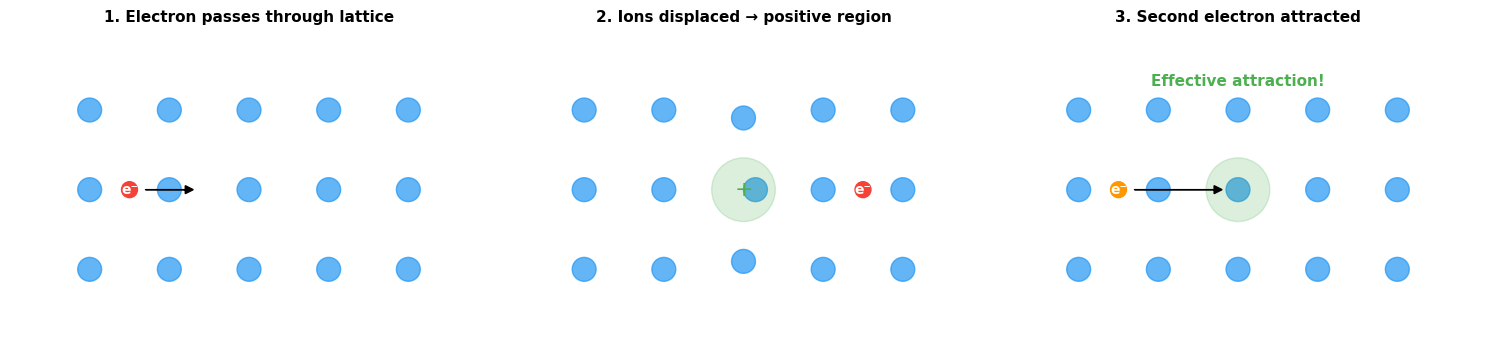

In [5]:
# Visualize: Phonon-mediated attraction
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax in axes:
    ax.set_xlim(-1, 5)
    ax.set_ylim(-1, 3)
    ax.set_aspect('equal')
    ax.axis('off')

# Step 1: Electron approaches
ax = axes[0]
ax.set_title('1. Electron passes through lattice', fontsize=11, fontweight='bold')
# Draw lattice ions
for i in range(5):
    for j in range(3):
        circle = Circle((i, j), 0.15, color=COLORS['primary'], alpha=0.7)
        ax.add_patch(circle)
# Draw electron
electron = Circle((0.5, 1), 0.1, color=COLORS['danger'])
ax.add_patch(electron)
ax.annotate('e⁻', (0.5, 1), fontsize=10, ha='center', va='center', color='white', fontweight='bold')
ax.arrow(0.7, 1, 0.5, 0, head_width=0.1, head_length=0.1, fc='black', ec='black')

# Step 2: Lattice distortion
ax = axes[1]
ax.set_title('2. Ions displaced → positive region', fontsize=11, fontweight='bold')
# Draw distorted lattice
for i in range(5):
    for j in range(3):
        # Displace ions near electron position
        dx = 0.15 if (i == 2 and j == 1) else 0
        dy = 0.1 if (i == 2 and j in [0, 2]) else 0
        dy = dy * (1 if j == 0 else -1)
        circle = Circle((i + dx, j + dy), 0.15, color=COLORS['primary'], alpha=0.7)
        ax.add_patch(circle)
# Highlight positive region
positive_region = Circle((2, 1), 0.4, color=COLORS['success'], alpha=0.2)
ax.add_patch(positive_region)
ax.annotate('+', (2, 1), fontsize=16, ha='center', va='center', color=COLORS['success'])
# Electron moved on
electron = Circle((3.5, 1), 0.1, color=COLORS['danger'])
ax.add_patch(electron)
ax.annotate('e⁻', (3.5, 1), fontsize=10, ha='center', va='center', color='white', fontweight='bold')

# Step 3: Second electron attracted
ax = axes[2]
ax.set_title('3. Second electron attracted', fontsize=11, fontweight='bold')
# Draw lattice
for i in range(5):
    for j in range(3):
        circle = Circle((i, j), 0.15, color=COLORS['primary'], alpha=0.7)
        ax.add_patch(circle)
# Positive region
positive_region = Circle((2, 1), 0.4, color=COLORS['success'], alpha=0.2)
ax.add_patch(positive_region)
# Second electron approaching
electron2 = Circle((0.5, 1), 0.1, color=COLORS['secondary'])
ax.add_patch(electron2)
ax.annotate('e⁻', (0.5, 1), fontsize=10, ha='center', va='center', color='white', fontweight='bold')
ax.arrow(0.7, 1, 1.0, 0, head_width=0.1, head_length=0.1, fc='black', ec='black')
ax.annotate('Effective attraction!', (2, 2.3), fontsize=11, ha='center', 
            color=COLORS['success'], fontweight='bold')

plt.tight_layout()
plt.show()

---
<a id="6-cooper-pairs"></a>
# 6. Cooper Pairs and the Energy Gap
---

### Cooper Pairs

Leon Cooper (1956) showed that an arbitrarily weak attractive interaction causes electrons near the Fermi surface to form **bound pairs**:

- Two electrons with **opposite spin** (↑↓) and **opposite momentum** (k, -k)
- **Binding energy**: 2Δ (the energy gap)
- **Size (coherence length ξ)**: Typically 100-1000 nm in conventional superconductors

Cooper pairs are **not** tightly bound molecules—they overlap extensively with many other pairs. All pairs condense into a **single macroscopic quantum state** described by:

$$\Psi = |\Psi|e^{i\phi}$$

where φ is the **macroscopic phase**—a property that will be crucial for Josephson junctions.

### The Energy Gap

Pairing opens an **energy gap** (2Δ) in the electronic density of states:

- Energy 2Δ required to break a Cooper pair into two quasiparticles
- No low-energy excitations available → no scattering → **zero resistance**

**BCS prediction (weak coupling):**

$$2\Delta(0) = 3.53 \, k_B T_c$$

| Material | T_c (K) | 2Δ (meV) | 2Δ/k_BT_c |
|----------|---------|----------|----------|
| Al | 1.2 | 0.34 | 3.3 |
| **Nb** | 9.2 | **3.0** | 3.8 |
| NbN | 16 | 5.0 | 3.6 |

In [6]:
# Calculate energy gap for niobium
k_B = 8.617e-5  # eV/K (Boltzmann constant)
Tc_Nb = 9.2     # K

# BCS prediction
Delta_0 = 1.764 * k_B * Tc_Nb  # in eV
two_Delta = 2 * Delta_0

print(f"Niobium (Nb) parameters:")
print(f"  Critical temperature T_c = {Tc_Nb} K")
print(f"  Energy gap Δ(0) = {Delta_0*1000:.3f} meV")
print(f"  Gap parameter 2Δ(0) = {two_Delta*1000:.2f} meV")
print(f"  Characteristic frequency = 2Δ/h = {two_Delta / (4.136e-15):.1f} GHz")
print(f"")
print(f"Physical meaning:")
print(f"  - Breaking one Cooper pair requires {two_Delta*1000:.2f} meV of energy")
print(f"  - At T << T_c, no thermal energy to break pairs → zero resistance")

Niobium (Nb) parameters:
  Critical temperature T_c = 9.2 K
  Energy gap Δ(0) = 1.398 meV
  Gap parameter 2Δ(0) = 2.80 meV
  Characteristic frequency = 2Δ/h = 676226158607.3 GHz

Physical meaning:
  - Breaking one Cooper pair requires 2.80 meV of energy
  - At T << T_c, no thermal energy to break pairs → zero resistance


### Characteristic Length Scales

| Parameter | Symbol | Physical Meaning | Typical Value (Nb) |
|-----------|--------|-----------------|-------------------|
| **Coherence length** | ξ | Size of Cooper pair | 38 nm |
| **Penetration depth** | λ | Magnetic field decay length | 90 nm |
| **GL parameter** | κ = λ/ξ | Type I/II classification | ~2.4 |

---
<a id="7-flux-quantization"></a>
# 7. Flux Quantization
---

In a superconducting loop, the magnetic flux is **quantized**:

$$\Phi = n\Phi_0$$

where n is an integer and:

$$\Phi_0 = \frac{h}{2e} = 2.067833848 \times 10^{-15} \text{ Wb}$$

### Why h/2e?

The factor of 2 arises because the current carriers are **Cooper pairs with charge 2e**. The experimental confirmation of flux quantization in 1961 provided key evidence for BCS theory.

### The Flux Quantum in Practice

The flux quantum Φ₀ is fundamental to superconducting electronics:

$$\Phi_0 = 2.07 \text{ mV·ps} = 2.07 \text{ mA·pH}$$

This sets the scale for:
- **Josephson junctions**: Voltage pulses with area = Φ₀
- **SQUIDs**: Sensitivity to fractions of Φ₀
- **SFQ logic**: One flux quantum = one bit of information

In [7]:
# Fundamental constants
h = 6.626e-34      # Planck constant (J·s)
e = 1.602e-19      # Elementary charge (C)

Phi_0 = h / (2 * e)  # Flux quantum

print("The Magnetic Flux Quantum")
print("=" * 40)
print(f"Φ₀ = h/2e = {Phi_0:.6e} Wb")
print(f"         = {Phi_0*1e15:.4f} fWb")
print(f"         = 2.07 mV·ps")
print(f"         = 2.07 mA·pH")
print()
print("Josephson frequency-voltage relation:")
print(f"  f = V/Φ₀ → 483.6 GHz per millivolt")
print()
print("In SFQ logic:")
print(f"  One flux quantum pulse ≈ 1-2 ps wide, ~1 mV amplitude")

The Magnetic Flux Quantum
Φ₀ = h/2e = 2.068040e-15 Wb
         = 2.0680 fWb
         = 2.07 mV·ps
         = 2.07 mA·pH

Josephson frequency-voltage relation:
  f = V/Φ₀ → 483.6 GHz per millivolt

In SFQ logic:
  One flux quantum pulse ≈ 1-2 ps wide, ~1 mV amplitude


---
<a id="8-why-sce"></a>
# 8. Why Superconductor Electronics?
---

Superconductivity enables electronics with extraordinary properties:

| Property | Value | Comparison to CMOS |
|----------|-------|-------------------|
| **Switching energy** | ~1.4 zJ (AQFP at 5 GHz) | 100,000× lower than 3nm CMOS |
| **Clock frequency** | 5-100+ GHz | 10-100× faster |
| **Power density** | ~pW/gate | Orders of magnitude lower |
| **Interconnect loss** | Zero (superconducting) | No IR drop |

### AQFP: The Focus of This Course

**Adiabatic Quantum-Flux-Parametron (AQFP)** is an ultra-low-power superconducting logic family:

- Operating temperature: **4.2 K** (liquid helium)
- Switching energy: **~1.4 zJ per junction** at 5 GHz (from Takeuchi IEEE JSSC)
- Clock frequency: **2.5-10 GHz** (MANA processor runs at 2.5 GHz)
- Energy efficiency: **~100× better than CMOS** at system level (after cooling overhead)
- Device-level advantage: **100,000×** vs CMOS

### The Energy Comparison

In [ ]:
# Energy comparison
fig, ax = plt.subplots(figsize=(10, 6))

technologies = ['CMOS 28nm', 'CMOS 7nm', 'CMOS 3nm', 'RSFQ', 'ERSFQ', 'AQFP']
energies = [35000, 13000, 140, 0.2, 0.02, 0.0014]  # in attojoules (aJ); AQFP = 1.4 zJ = 0.0014 aJ, RSFQ = 0.2 aJ
colors = [COLORS['normal'], COLORS['normal'], COLORS['normal'], COLORS['primary'], COLORS['primary'], COLORS['superconducting']]

bars = ax.barh(technologies, energies, color=colors)
ax.set_xscale('log')
ax.set_xlabel('Energy per Operation (aJ)', fontsize=12)
ax.set_title('Switching Energy by Technology', fontsize=14, fontweight='bold')
ax.set_xlim(0.0001, 100000)
ax.grid(True, alpha=0.3, axis='x')

# Annotate values
for bar, energy in zip(bars, energies):
    if energy < 0.01:
        label = f'{energy*1000:.1f} zJ'
    elif energy < 1:
        label = f'{energy:.2f} aJ'
    else:
        label = f'{energy:,.0f} aJ'
    ax.text(energy * 2, bar.get_y() + bar.get_height()/2, 
            label, va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"AQFP is {140/0.0014:,.0f}× more energy efficient than 3nm CMOS per operation (device level).")
print(f"With ~1000× cooling overhead at 4.2 K, still ~100× better at system level.")

### The Opportunity: AI Acceleration

AI compute demand is growing exponentially (~4× per year), hitting power limits:

- Training frontier models: **10-100 MW** data centers
- Single H100 GPU: **700 W**
- Scaling to AGI: Unsustainable with current technology

Superconducting electronics offers a path forward—ultra-efficient compute at cryogenic temperatures. This course will give you the foundation to contribute to this emerging field.

### The SCE Landscape

Superconducting electronics is an active field with multiple companies and research groups pursuing different applications:

| Organization | Focus | Approach |
|--------------|-------|----------|
| **Google Quantum AI** | Qubit control | SFQ for fast pulse generation |
| **SeeQC** | Quantum co-processing | SFQ-based digital control |
| **Hypres** (now SeeQC) | SFQ electronics | RSFQ pioneers, ADCs, digital RF |
| **MIT Lincoln Lab** | Fabrication & research | Advanced SCE processes, SFQ |
| **NIST** | Metrology & standards | Josephson voltage standards, quantum |
| **Yokohama National / AIST** | Ultra-low-power compute | AQFP research & MANA processor |
| **imec / SkyWater** | Foundry services | SCE fabrication infrastructure |

**Why the different approaches?**

- **Quantum control** needs fast, precise pulses → SFQ excels (picosecond switching, high bandwidth)
- **Classical compute** needs energy efficiency → AQFP excels (zeptojoule switching, adiabatic operation)

This course focuses on **AQFP for AI acceleration**—the ultra-low-power path to sustainable large-scale compute.

---
## Summary

- Superconductivity = **zero resistance** + **Meissner effect** below T_c
- **BCS theory** explains superconductivity via Cooper pairs and the energy gap
- **Type II superconductors** (like Nb) are used in most devices
- **Flux quantization** (Φ₀ = h/2e) is fundamental to superconducting electronics
- **AQFP** achieves ~1.4 zJ switching energy—100,000× better than CMOS at device level

### Key Numbers to Remember

| Parameter | Value |
|-----------|-------|
| **Flux quantum Φ₀** | 2.07 × 10⁻¹⁵ Wb = 2.07 mV·ps |
| **Nb critical temp T_c** | 9.2 K |
| **Nb energy gap 2Δ** | 2.7-3.0 meV |
| **Nb IcRn product** | ~1.8 mV |
| **Josephson constant** | 483.6 GHz/mV |
| **AQFP energy** | 1.4 zJ/JJ at 5 GHz |
| **AQFP system advantage** | ~100× vs CMOS (after cooling) |

### Next Session
**Superconducting Materials** — Which superconductors do we use and why?